# Theory

1. select dorsal ventral gridnet associated genes (Bennet's csv):
    - p-vale less 0.05
    - abs(corr) more 0.1
2. log(norm) raw counts --> of **NOT perturbed** data
3. score = dot(log_norm, corr_selected_spatial_genes)
4. take adat **WITH pertubation**:
    - in **ONLY diseased samples** remove pct cells that are msot dorsal

**HIGH SCORE = MORE DORSAL**

In [1]:
%load_ext autoreload
%autoreload 2

import scanpy as sc
import pandas as pd
import numpy as np
import os
import gc
import matplotlib.pyplot as plt

from utils import preprocessing
from utils import DEG
%matplotlib inline

# Attention the follwing adata mus be create .qs --> h5ad
GENESET="004"
ADATA_TO_CREATE_DEPLETED_VERSIONS = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{GENESET}/initial_perturbed/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1.0_raw.h5ad"
adata_to_create_depleyed_versions_folder = f"{os.path.split(ADATA_TO_CREATE_DEPLETED_VERSIONS)[0]}/../depleted_versions/"
print(adata_to_create_depleyed_versions_folder)
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results

DEPLETION_PERCENTS = ["0.00", "0.10", "0.20", "0.30", "0.40", "0.50", "0.60", "0.70", "0.80"]

CONTRAST_VARIABLE = "case_control"
CONTRAST_VARIABLE_HEALTHY = "control"
CONTRAST_VARIABLE_DISEASED = "case"
DONOR_ID_VARIABLE = "donor_id"
CT_COL = "spn_type"
CTS_TO_SUBSET = ["ventral_matrix", "dorsal_matrix"]

# PSUDOBULK paramters
COV_FOR_PSEUDOBULK = None #[celltype] #in addition top donor_id
# Obs col names that groups psudocells in groups in which perfomr DEG in them --> it is made using the var in COV_FOR_PSEUDOBULK
GROUP_DEG_COL = "pseudobulk_group_for_DEG"
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic"]
# Cov to have in pesudbulked data that are interesing to not òose
INTERESTING_COV = []
# Filter varibales for pseudobulk cells
MIN_CELLS_PER_PSUDOCELL=10
MIN_COUNTS_PER_PSEUDOCELL=1000
MIN_PSEUDOCELL_PER_GROUP=2
# Filter gens noisy/low expressed
MIN_COUNTS=10
LARGE_N=10
MIN_TOTAL_COUNTS=15
MIN_PROP_BY_EXPR=0.3
MIN_PROP_BY_PROP=0.1
MIN_SMPLS=2

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_004/initial_perturbed/../depleted_versions/


# Calculate Gradient score

ATTENTION: need to do only once for all geneset. It is calculated on the origal data (before perturbing).

In [2]:
# adata with all samples bican (before applying perturbation) --> used to calculate gradient-score
ADATA_ALL_SAMPLES = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples/zonated_objs_combined_with_md.h5ad"

# path to garine tgenes corr lsit
GRADIENT_DF_PATH = "/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv"

# thr to be graidnet gene (CORRELATION)
THR_GRADIENT_GENE = 0.1

#
save_grad_csv_path= f"{os.path.split(ADATA_ALL_SAMPLES)[0]}/gradient-scores.csv"

In [3]:
# adata = sc.read_h5ad(ADATA_ALL_SAMPLES)#, backed="r")

# # Filter to only ventral and dorsal matrix
# #adata = adata[adata.obs[CT_COL].isin(CTS_TO_SUBSET)].to_memory().copy()

# adata

In [4]:
# # Normalise
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

In [5]:
# # Define gene sets
# df_grad = pd.read_csv(GRADIENT_DF_PATH)

# # Select siognficant
# df_grad = df_grad[(df_grad.combined_p <= 0.05) & (np.abs(df_grad.mean_spearman) >= THR_GRADIENT_GENE)]

# df_grad

In [6]:
# # calculate score per cell

# common_genes = adata.var_names.intersection(df_grad.gene)
# print(f"{len(common_genes)} common genes")

# X_grad_genes = adata[:, common_genes].X  # (n_cells × n_genes)
# print(X_grad_genes.shape)

# df_grad = (
#     df_grad.copy()
#     .set_index("gene")
#     .loc[common_genes]
# )

# # more dorsal genes --> higher score
# adata.obs["gradient_score"] = - X_grad_genes @ df_grad.mean_spearman.values

# scores = adata.obs["gradient_score"]
# p80 = np.percentile(scores, 100-80)
# ax = scores.plot(kind="hist", bins=100)
# ax.axvline(p80, color="red", linestyle="--", linewidth=2)
# plt.show()


In [7]:
# # save
# df = adata.obs[["gradient_score"]]#.reset_index(names="barcode")
# display(df)
# df.to_csv(save_grad_csv_path)


# Make % depleted datasets

In [8]:
adata_pert_complete = sc.read_h5ad(ADATA_TO_CREATE_DEPLETED_VERSIONS, backed="r")

# ATTENTION: Subset to specific cell type
adata_pert_complete = adata_pert_complete[adata_pert_complete.obs[CT_COL].isin(CTS_TO_SUBSET)].to_memory().copy()

# Add greaidnet score
df_grad = pd.read_csv(save_grad_csv_path, index_col=0)
adata_pert_complete.obs = adata_pert_complete.obs.merge(df_grad, how="left", left_index=True, right_index=True, validate="one_to_one")
# Check that all cells have scores
assert not adata_pert_complete.obs['gradient_score'].isna().any(), "Some cells have no gradient scores!"

adata_pert_complete.obs

,orig.ident,nCount_RNA,nFeature_RNA,Row.names,donor_id,PREFIX,CELL_BARCODE,NUM_GENIC_READS,NUM_TRANSCRIPTS,NUM_GENES,...,PC_22,PC_23,PC_24,PC_25,PC_26,PC_27,PC_28,PC_29,PC_30,gradient_score
STR_D1_Matrix_MSN_s5_s5_AACAGGAGTGCACGTA_1,2024-10-25,149923.0,11741,STR_D1_Matrix_MSN_s5_s5_AACAGGAGTGCACGTA_1,PT13935,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn1,AACAGGAGTGCACGTA,277637.0,144692.0,11294,...,0.607858,0.697795,6.405210,-2.009196,-3.405424,2.366665,-0.848699,-5.111074,0.825016,35.988401
STR_D1_Matrix_MSN_s5_s5_ACATTGGTCGGGTATC_1,2024-10-25,105479.0,10583,STR_D1_Matrix_MSN_s5_s5_ACATTGGTCGGGTATC_1,PT13935,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn1,ACATTGGTCGGGTATC,190494.0,101946.0,10148,...,-0.670362,0.337599,2.082217,-2.006704,-0.411461,0.413978,-1.031831,-0.875825,2.206928,29.476470
STR_D1_Matrix_MSN_s5_s5_ATTGCATAGACCAATT_1,2024-10-25,86852.0,9882,STR_D1_Matrix_MSN_s5_s5_ATTGCATAGACCAATT_1,PT13935,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn1,ATTGCATAGACCAATT,162550.0,84177.0,9521,...,-4.374092,2.719627,1.837517,-0.037854,1.833244,-3.576310,-2.116828,1.171342,2.274845,11.979222
STR_D1_Matrix_MSN_s5_s5_CGGATATGTCTCGATC_1,2024-10-25,106760.0,10208,STR_D1_Matrix_MSN_s5_s5_CGGATATGTCTCGATC_1,PT13935,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn1,CGGATATGTCTCGATC,188163.0,103243.0,9806,...,-1.399021,0.584212,0.882658,-1.692326,-1.702649,0.560821,0.119049,-0.411592,0.241999,52.579398
STR_D1_Matrix_MSN_s5_s5_ACCATTCTCCAGTATG_1,2024-10-25,192167.0,12403,STR_D1_Matrix_MSN_s5_s5_ACCATTCTCCAGTATG_1,PT13935,2024-10-25_s5_Slide-tag_10X-GEMX-5P-GEX_BN_rxn1,ACCATTCTCCAGTATG,350861.0,185103.0,11868,...,0.848318,0.563175,1.408173,-1.248660,-4.590993,3.915814,-2.539309,-0.824064,3.083104,59.063171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s38_2025-06-04_s38_GEX_CAP_rxn4_AGTCCGGTCCGACTAA,2025-06-04,74971.0,9894,s38_2025-06-04_s38_GEX_CAP_rxn4_AGTCCGGTCCGACTAA,MS986638,2025-06-04_s38_GEX_CAP_rxn4,AGTCCGGTCCGACTAA,405818.0,72648.0,9608,...,-0.030470,-0.224181,-3.897851,-3.059319,-1.677981,1.235152,1.434013,0.074378,-1.405352,22.443056
s38_2025-06-04_s38_GEX_CAP_rxn4_ACATAGAAGATATTGC,2025-06-04,80296.0,9787,s38_2025-06-04_s38_GEX_CAP_rxn4_ACATAGAAGATATTGC,MS986638,2025-06-04_s38_GEX_CAP_rxn4,ACATAGAAGATATTGC,470206.0,78416.0,9503,...,-1.630058,-0.468492,-3.612088,0.055635,-2.612206,-0.405833,1.995562,1.743880,-5.035184,28.895304
s38_2025-06-04_s38_GEX_CAP_rxn4_CGTTTCAGTCTGTATT,2025-06-04,67601.0,9804,s38_2025-06-04_s38_GEX_CAP_rxn4_CGTTTCAGTCTGTATT,MS986638,2025-06-04_s38_GEX_CAP_rxn4,CGTTTCAGTCTGTATT,391080.0,66107.0,9581,...,-0.342663,0.233094,-3.010377,1.996621,-2.086340,-1.533372,0.195841,1.244902,-2.308179,42.848319
s38_2025-06-04_s38_GEX_CAP_rxn4_ACGTCCGAGCTGGCAT,2025-06-04,52648.0,8373,s38_2025-06-04_s38_GEX_CAP_rxn4_ACGTCCGAGCTGGCAT,MS986638,2025-06-04_s38_GEX_CAP_rxn4,ACGTCCGAGCTGGCAT,254628.0,51211.0,8132,...,-0.431708,0.717595,-1.452508,1.944782,-0.940623,-1.132167,1.035657,1.008899,-1.720228,25.220636


In [9]:
# *)make a healthy ONLY version (some mtheods are fittedf only on thesse)
only_healhty_save_path = f"{os.path.split(ADATA_ALL_SAMPLES)[0]}/depleted_dorsal_matrix/depleted_dorsal_matrix_healthy.h5ad"
if not os.path.exists(only_healhty_save_path):
    print(only_healhty_save_path)
    adata_pert_complete[adata_pert_complete.obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_HEALTHY].copy().write(only_healhty_save_path)

# *)make ALL D+H version (BUT WITH CURRENT SUBSET OF CELL TYPES) NO DEPLETION
only_cell_types_path = f"{os.path.split(ADATA_ALL_SAMPLES)[0]}/depleted_dorsal_matrix/depleted_dorsal_matrix_all.h5ad"
if not os.path.exists(only_cell_types_path):
    print(only_cell_types_path)
    adata_pert_complete.write(only_cell_types_path)

0.00


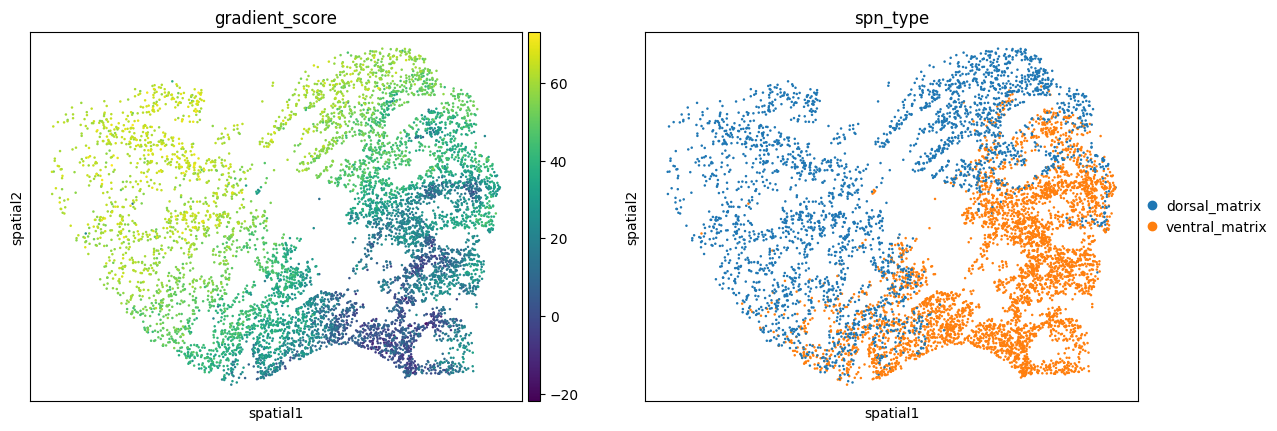

	Saving h5ad...
	Saving files for R coversion...
	Building R obj...


2026-02-09 15:36:58 | [WARNING] R callback write-console: Loading required package: SeuratObject
  
2026-02-09 15:36:58 | [WARNING] R callback write-console: Loading required package: sp
  
2026-02-09 15:37:00 | [WARNING] R callback write-console: 
Attaching package: ‘SeuratObject’

  
2026-02-09 15:37:00 | [WARNING] R callback write-console: The following objects are masked from ‘package:base’:

    %||%, intersect, t

  



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

2026-02-09 15:37:03 | [WARNING] R callback write-console: 
Attaching package: ‘Seurat’

  
2026-02-09 15:37:03 | [WARNING] R callback write-console: The following object is masked from ‘package:base’:

    %||%

  
2026-02-09 15:37:03 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  



Setting case_control reference level to: control
Levels: control case 
[1] "Creating Seurat object..."


2026-02-09 15:45:28 | [WARNING] R callback write-console: Warning:  
2026-02-09 15:45:28 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
	Saving pseudobulk...

Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [1.1110e+03 3.5510e+03 6.3000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2670e+03 5.4300e+03 1.5000e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.0050e+03 5.9330e+03 1.0700e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

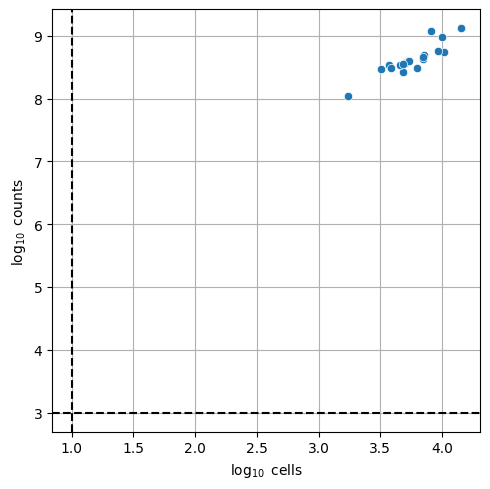

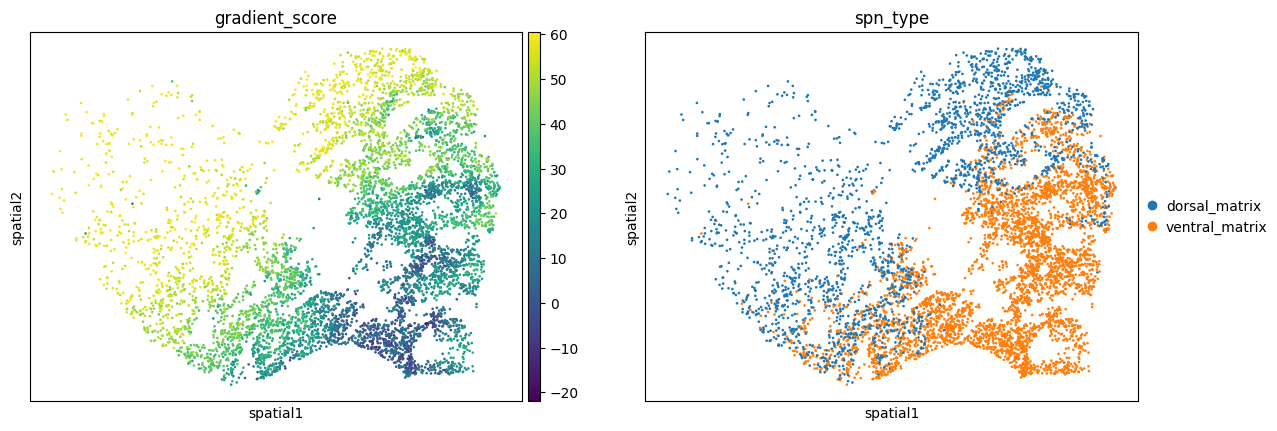

	Saving h5ad...
	Saving files for R coversion...
	Building R obj...

Setting case_control reference level to: control
Levels: control case 
[1] "Creating Seurat object..."


2026-02-09 15:59:51 | [WARNING] R callback write-console: Warning:  
2026-02-09 15:59:51 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
	Saving pseudobulk...

Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [1.0240e+03 3.1760e+03 5.7000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.0600e+03 4.8740e+03 1.3900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.8720e+03 5.3950e+03 9.7000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

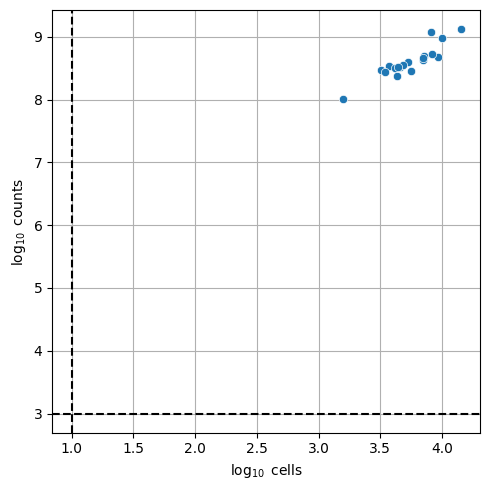

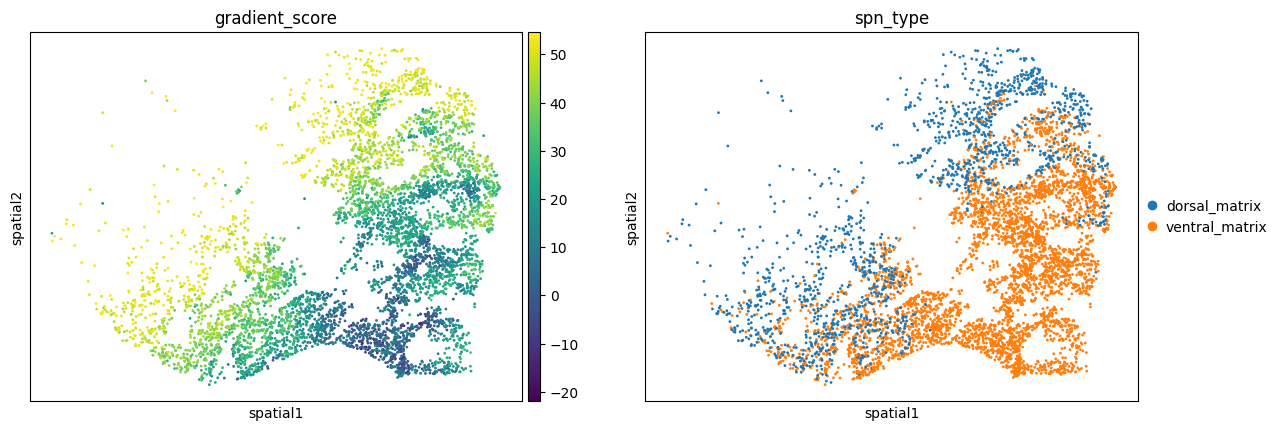

	Saving h5ad...
	Saving files for R coversion...
	Building R obj...

Setting case_control reference level to: control
Levels: control case 
[1] "Creating Seurat object..."


2026-02-09 16:12:40 | [WARNING] R callback write-console: Warning:  
2026-02-09 16:12:40 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
	Saving pseudobulk...

Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [9.1200e+02 2.8490e+03 5.1000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.8620e+03 4.3160e+03 1.2900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.7230e+03 4.8520e+03 8.9000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

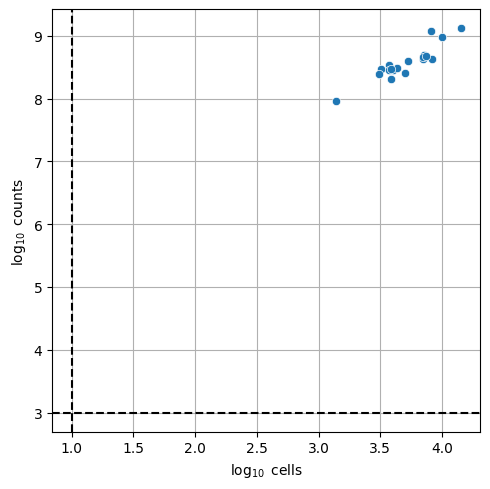

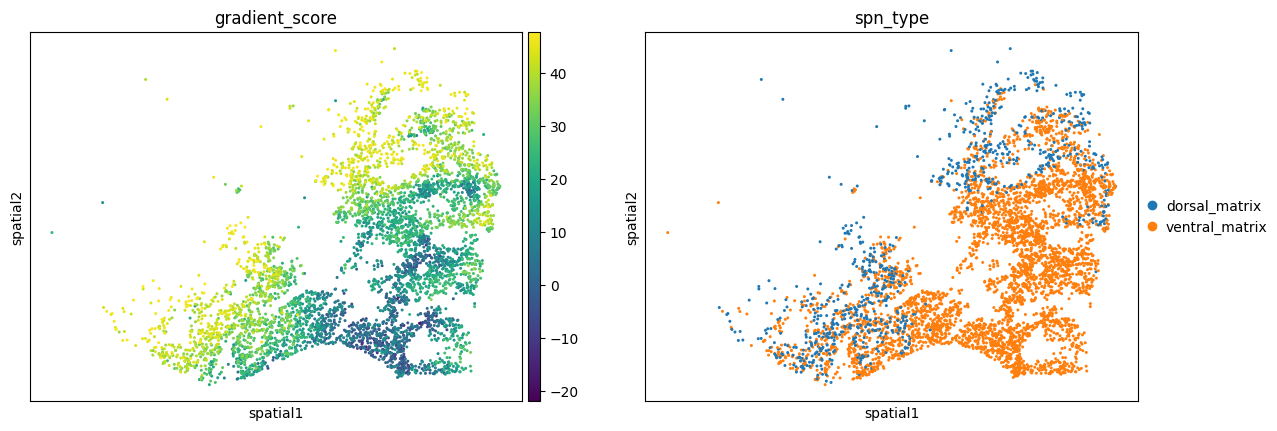

	Saving h5ad...
	Saving files for R coversion...
	Building R obj...

Setting case_control reference level to: control
Levels: control case 
[1] "Creating Seurat object..."


2026-02-09 16:24:41 | [WARNING] R callback write-console: Warning:  
2026-02-09 16:24:41 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
	Saving pseudobulk...

Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [8.1700e+02 2.5100e+03 4.3000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.6260e+03 3.7590e+03 1.1300e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.5490e+03 4.2780e+03 8.1000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

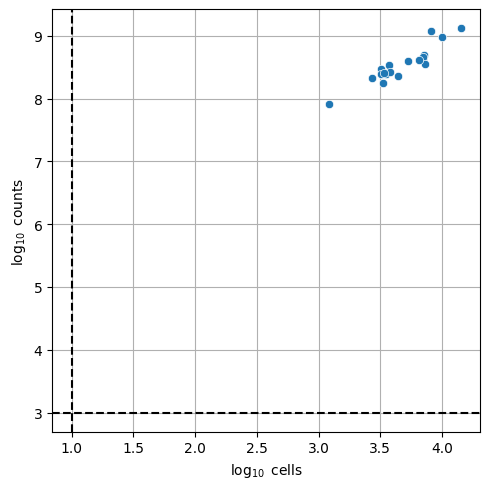

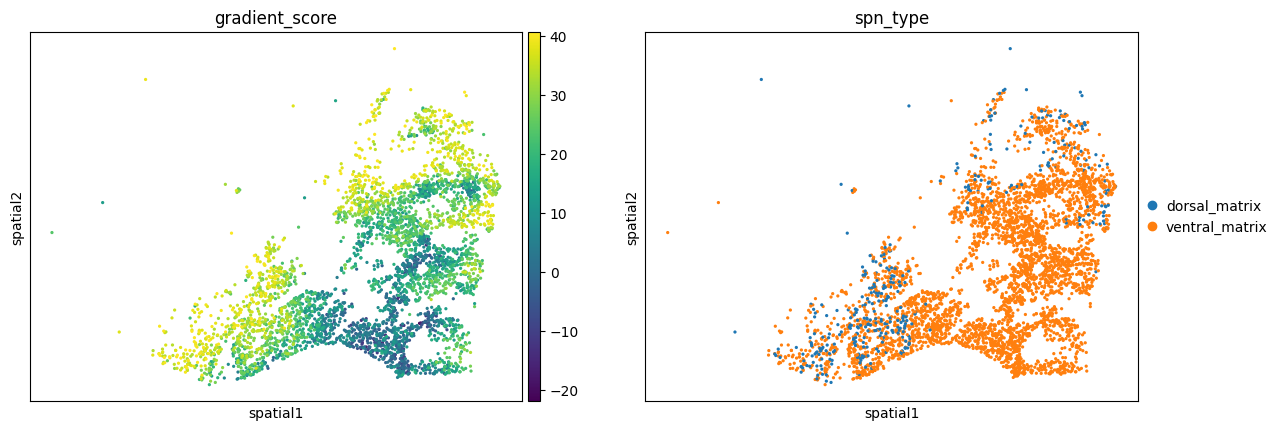

	Saving h5ad...
	Saving files for R coversion...
	Building R obj...

Setting case_control reference level to: control
Levels: control case 
[1] "Creating Seurat object..."


2026-02-09 16:36:41 | [WARNING] R callback write-console: Warning:  
2026-02-09 16:36:41 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
	Saving pseudobulk...

Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [7.2100e+02 2.1440e+03 3.9000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.3980e+03 3.2100e+03 9.1000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.3850e+03 3.7280e+03 7.7000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

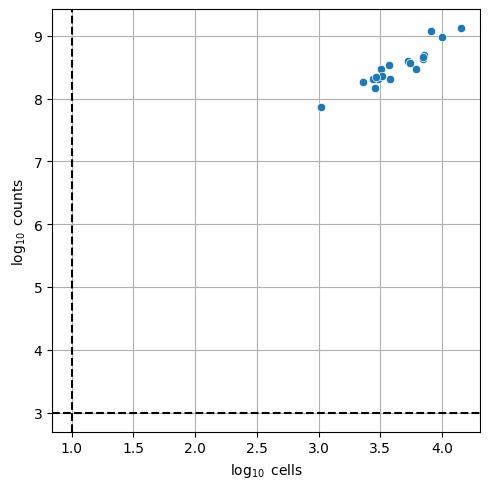

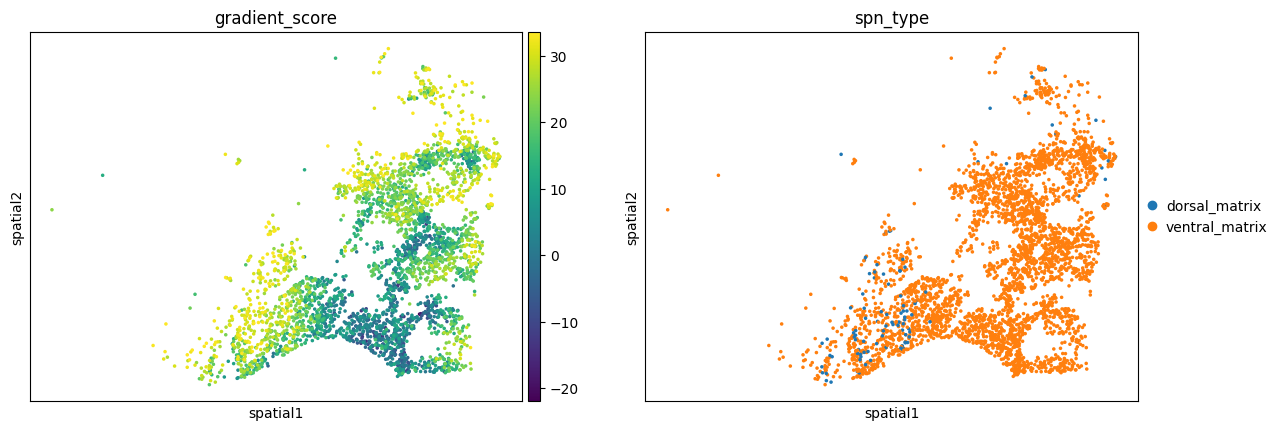

	Saving h5ad...
	Saving files for R coversion...
	Building R obj...

Setting case_control reference level to: control
Levels: control case 
[1] "Creating Seurat object..."


2026-02-09 16:47:46 | [WARNING] R callback write-console: Warning:  
2026-02-09 16:47:46 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
	Saving pseudobulk...

Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [6.1400e+02 1.7550e+03 3.4000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.1840e+03 2.6530e+03 7.2000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.2160e+03 3.1400e+03 7.0000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

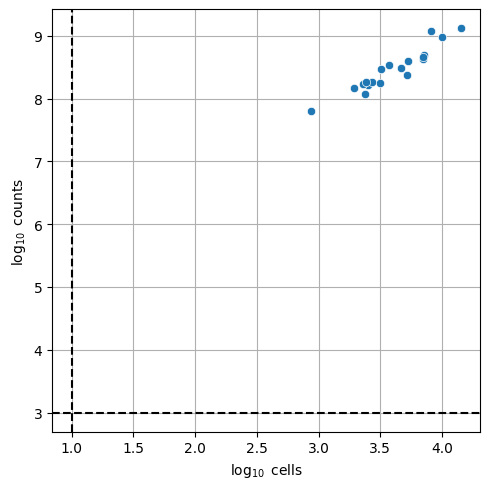

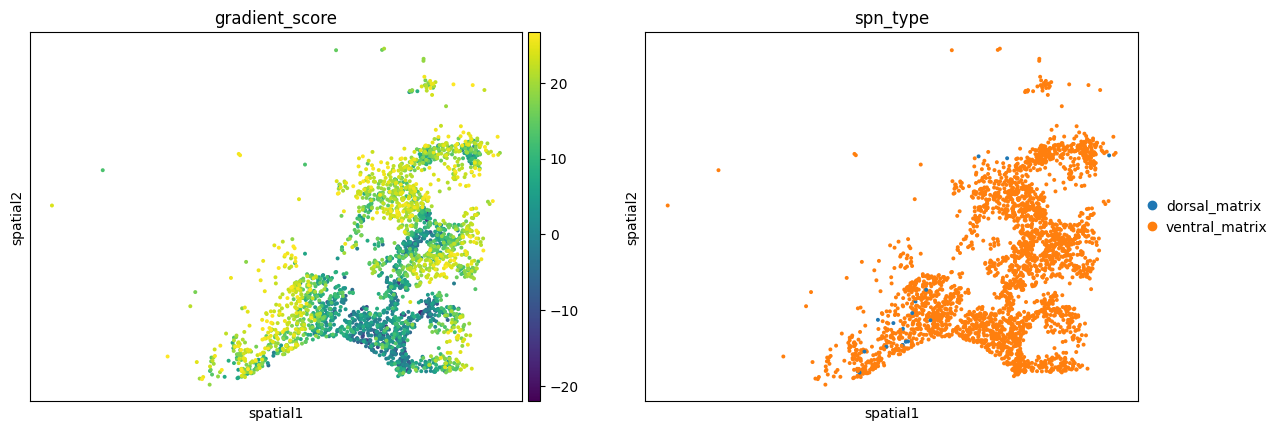

	Saving h5ad...
	Saving files for R coversion...
	Building R obj...

Setting case_control reference level to: control
Levels: control case 
[1] "Creating Seurat object..."


2026-02-09 16:57:49 | [WARNING] R callback write-console: Warning:  
2026-02-09 16:57:49 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
	Saving pseudobulk...

Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [4.9400e+02 1.3820e+03 2.9000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [9.5700e+02 2.0970e+03 5.2000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.0160e+03 2.4970e+03 5.5000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

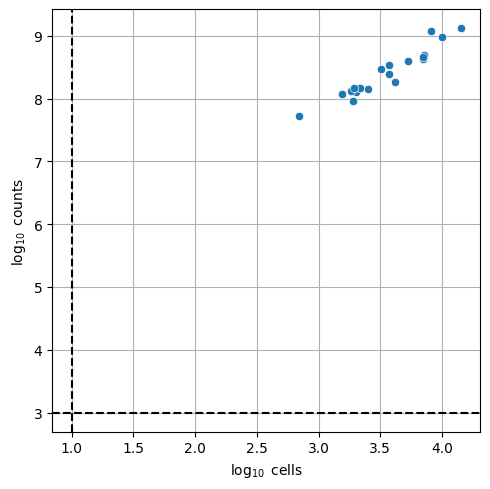

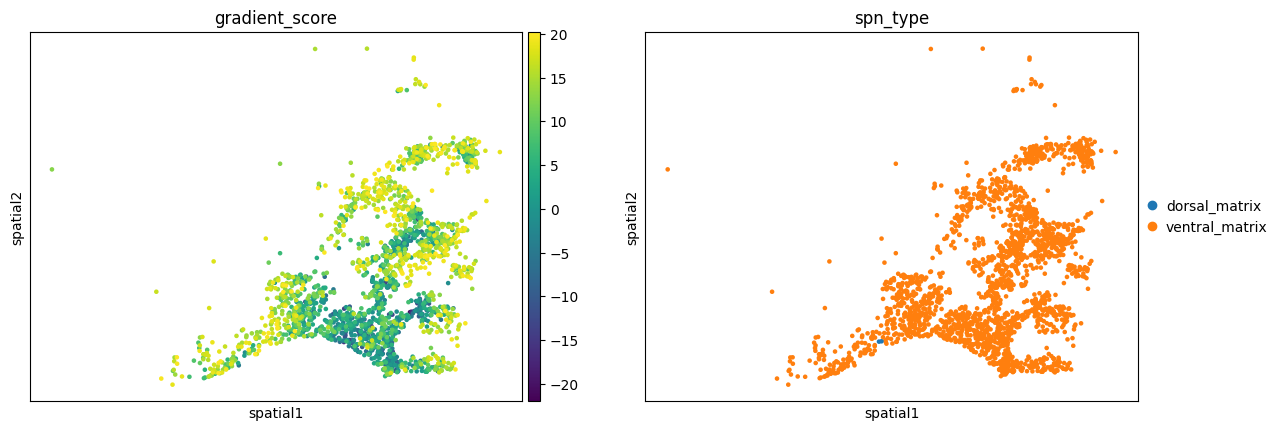

	Saving h5ad...
	Saving files for R coversion...
	Building R obj...

Setting case_control reference level to: control
Levels: control case 
[1] "Creating Seurat object..."


2026-02-09 17:08:08 | [WARNING] R callback write-console: Warning:  
2026-02-09 17:08:08 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
	Saving pseudobulk...

Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [3.8200e+02 1.0110e+03 2.1000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [7.5100e+02 1.6060e+03 4.0000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [7.8000e+02 1.9500e+03 3.7000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

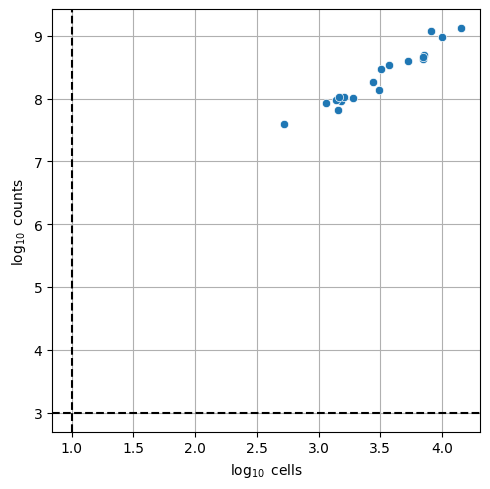

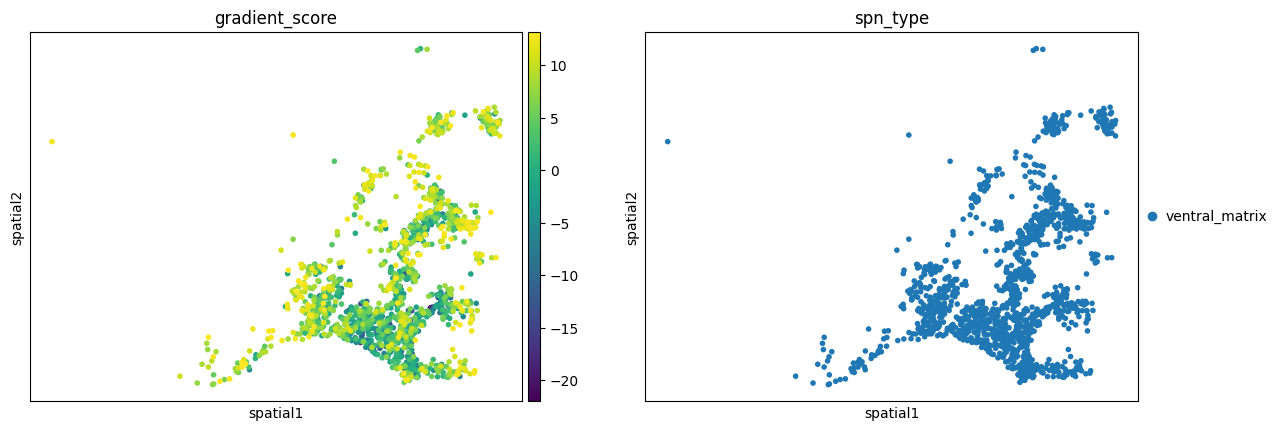

	Saving h5ad...
	Saving files for R coversion...
	Building R obj...

Setting case_control reference level to: control
Levels: control case 
[1] "Creating Seurat object..."


2026-02-09 17:17:16 | [WARNING] R callback write-console: Warning:  
2026-02-09 17:17:16 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
	Saving pseudobulk...

Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [2.5900e+02 6.1900e+02 1.5000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [5.0300e+02 1.0800e+03 3.1000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [5.3400e+02 1.3250e+03 2.7000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

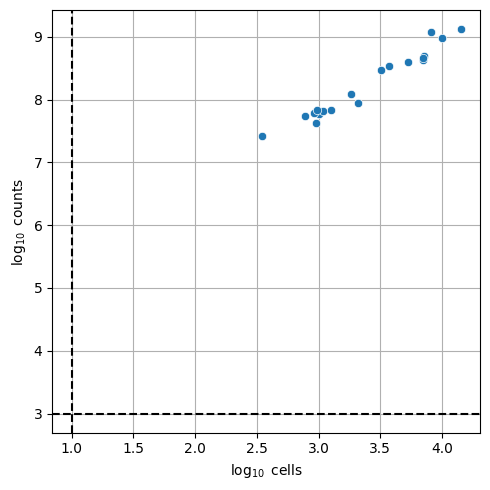

In [10]:
for pct in DEPLETION_PERCENTS:
    print(pct)

    save_folder = os.path.join(adata_to_create_depleyed_versions_folder, f"depleted_{pct}_dorsal_matrix",)
    save_path_h5ad = os.path.join(save_folder, f"depleted_{pct}_dorsal_matrix.h5ad")
    save_path_pseudobulked = os.path.join(save_folder, f"depleted_{pct}_dorsal_matrix_pseudobulked.h5ad")
    save_path_qs = os.path.join(save_folder, f"depleted_{pct}_dorsal_matrix.qs")
    os.makedirs(save_folder, exist_ok=True)

    if (os.path.exists(save_path_h5ad)) & (os.path.exists(save_path_qs)):
        print(f"\tFiles already exist, skipping...")
        continue

    # take out ily obs 
    obs = adata_pert_complete.obs.copy()
    
    # Get healthy cells (keep all)
    healthy_mask = obs[CONTRAST_VARIABLE] != CONTRAST_VARIABLE_DISEASED
    
    # Get diseased cells and their gradient scores
    diseased_mask = obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_DISEASED
    diseased_obs = obs[diseased_mask].copy()
    
    # For each diseased sample, mark cells to keep
    cells_to_keep_mask = healthy_mask.copy()  # Start with all healthy cells
    
    for sample_id in diseased_obs[DONOR_ID_VARIABLE].unique():
        # Get cells from this sample
        sample_mask = (diseased_obs[DONOR_ID_VARIABLE] == sample_id)
        sample_cells = diseased_obs[sample_mask]
        
        # Calculate how many to keep
        n_cells = len(sample_cells)
        n_cells_to_keep = int(n_cells * (1 - float(pct)))
        
        # Sort by gradient score and get bottom cells to keep (remove the most dorsal)
        sorted_cells = sample_cells.sort_values('gradient_score')
        cells_to_keep_ids = sorted_cells.index[:n_cells_to_keep]   # Keeps LOWEST scores
        
        # Mark these cells to keep
        cells_to_keep_mask[cells_to_keep_ids] = True
    
    # Single subset operation on backed adata
    adata_pert_tmp = adata_pert_complete[cells_to_keep_mask]

    # Save scores
    #adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']

    # at the end of each lopp chekc one sample
    sample_id = "MS986638" #adata_pert_tmp.obs[adata_pert_tmp.obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_DISEASED][DONOR_ID_VARIABLE].unique()[0]
    adata_s = adata_pert_tmp[adata_pert_tmp.obs[DONOR_ID_VARIABLE] == sample_id].to_memory().copy()
    adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
    sc.pl.embedding(adata_s, basis="spatial", color=["gradient_score", "spn_type"])
    del adata_s


    # Save the subsetted adata
    print("\tSaving h5ad...")
    adata_pert_tmp.write_h5ad(save_path_h5ad)

    ########################

    # CONVERT TO QS

    print("\tSaving files for R coversion...")
    preprocessing.save_files_for_R_conversion(adata_pert_tmp, QS_TMP_FOLDER)
    print("\tBuilding R obj...")
    preprocessing.build_qs_from_python_files(
        QS_TMP_FOLDER, saving_path=save_path_qs, 
        contrast_var=CONTRAST_VARIABLE, reference_level=CONTRAST_VARIABLE_HEALTHY)

    #########################

    # SAVE PSEUDOBULK
    print("\tSaving pseudobulk...")
    adata_pb_all = DEG.pseudobulk(adata_pert_tmp, DONOR_ID_VARIABLE, COV_FOR_PSEUDOBULK, GROUP_DEG_COL, COVARIATES_FOR_DEG=COVARIATES_FOR_DEG, INTERESTING_COV=INTERESTING_COV,
            MIN_CELLS_PER_PSUDOCELL=MIN_CELLS_PER_PSUDOCELL,MIN_COUNTS_PER_PSEUDOCELL=MIN_COUNTS_PER_PSEUDOCELL, filter_genes=True, layer=None,
            MIN_COUNTS=MIN_COUNTS,LARGE_N=LARGE_N, MIN_TOTAL_COUNTS=MIN_TOTAL_COUNTS, MIN_PROP_BY_EXPR=MIN_PROP_BY_EXPR,MIN_PROP_BY_PROP=MIN_PROP_BY_PROP,MIN_SMPLS=MIN_SMPLS, )
    adata_pb_all.write_h5ad(save_path_pseudobulked)
    
    del adata_pert_tmp, adata_pb_all
    gc.collect()

print("Done")

# Verify dorsal.gradient

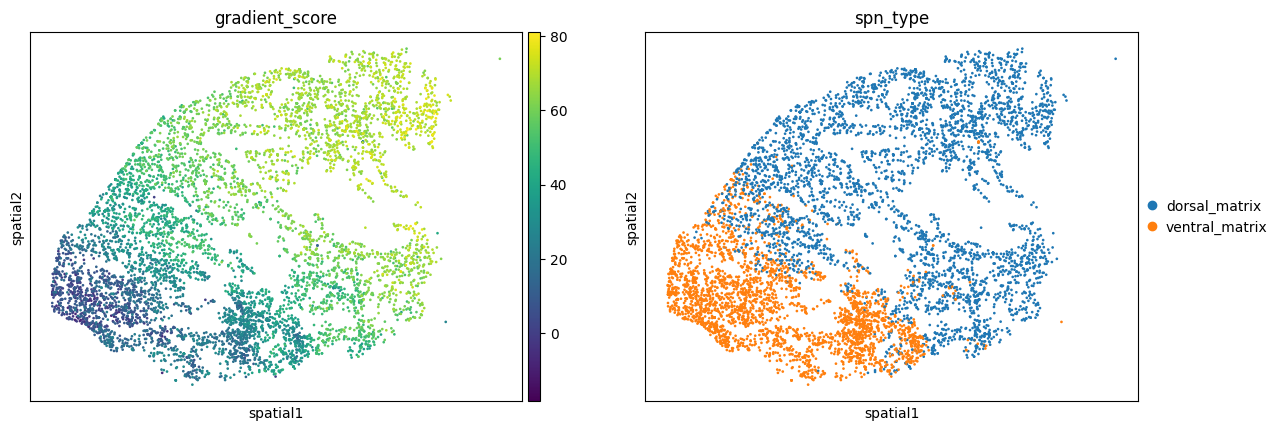

In [11]:
adata_s = adata_pert_complete[adata_pert_complete.obs.donor_id == "PT13935"].to_memory().copy()
adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
sc.pl.embedding(adata_s, basis="spatial", color=["gradient_score", "spn_type"])